In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

# IBVS

In [2]:
# cartesian pose
fp = open("/home/logesh/fanuc_ws/src/visual-servoing-pkg/pose_logs/ibvs_ee_pose.csv")
str_lines = fp.readlines()
ibvs_ee_pose = []
for line in str_lines:
    arr = list(map(float, line.split(',')))
    ibvs_ee_pose.append(arr)
ibvs_ee_pose = np.array(ibvs_ee_pose)

print(ibvs_ee_pose.shape)

(279, 6)


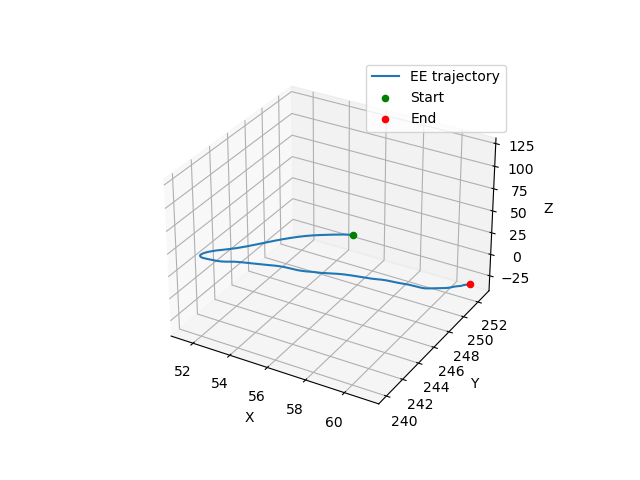

In [3]:
%matplotlib widget

# plot ee-Pose

# Extract translation
x = ibvs_ee_pose[:, 0]
y = ibvs_ee_pose[:, 1]
z = ibvs_ee_pose[:, 2]

# 3D Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z, label="EE trajectory")
ax.scatter(x[0], y[0], z[0], color='green', label="Start")
ax.scatter(x[-1], y[-1], z[-1], color='red', label="End")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()

In [4]:
# distance convered in IBVS
total_distance = 0
for idx in range(1, len(ibvs_ee_pose)):
    pt1 = ibvs_ee_pose[idx-1][0:3]
    pt2 = ibvs_ee_pose[idx][0:3]
    dist = np.linalg.norm(pt2 - pt1)
    total_distance += dist

print("IBVS Analysis:")
print("Arc Distance:", round(total_distance, 4), "mm")
print("Time taken to converge:", 18.125, "sec")
# np.linalg.norm(ibvs_ee_pose[-1][0:3] - ibvs_ee_pose[0][0:3])

IBVS Analysis:
Arc Distance: 154.6905 mm
Time taken to converge: 18.125 sec


# PBVS

In [5]:
# cartesian pose
fp = open("/home/logesh/fanuc_ws/src/visual-servoing-pkg/pose_logs/pbvs_ee_pose.csv")
str_lines = fp.readlines()
pbvs_ee_pose = []
for line in str_lines:
    arr = list(map(float, line.split(',')))
    pbvs_ee_pose.append(arr)
pbvs_ee_pose = np.array(pbvs_ee_pose)

print(pbvs_ee_pose.shape)

(816, 6)


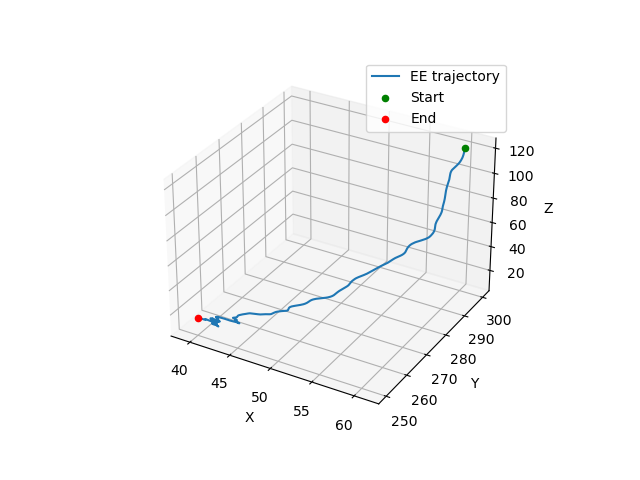

In [6]:
%matplotlib widget

# plot ee-Pose

# Extract translation
x = pbvs_ee_pose[:, 0]
y = pbvs_ee_pose[:, 1]
z = pbvs_ee_pose[:, 2]

# 3D Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z, label="EE trajectory")
ax.scatter(x[0], y[0], z[0], color='green', label="Start")
ax.scatter(x[-1], y[-1], z[-1], color='red', label="End")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()

In [7]:
# distance convered in PBVS
total_distance = 0
for idx in range(1, len(pbvs_ee_pose)):
    pt1 = pbvs_ee_pose[idx-1][0:3]
    pt2 = pbvs_ee_pose[idx][0:3]
    dist = np.linalg.norm(pt2 - pt1)
    total_distance += dist

print("PBVS Analysis:")
print("Arc Distance:", round(total_distance, 4), "mm")
print("Time taken to converge:", 37.066, "sec")
# np.linalg.norm(pbvs_ee_pose[0][0:3] - pbvs_ee_pose[-1][0:3])

PBVS Analysis:
Arc Distance: 135.5358 mm
Time taken to converge: 37.066 sec
